<a href="https://colab.research.google.com/github/YumnaHaniffa/Customer-Churn-Prediction/blob/main/Component_1_DPP%26DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Component based data preprocessing

"To generate a weekly probability score (0-1) for next week  for every GN Division, specific to a user-selected crime type, by analyzing historical trends, land use, and spatial lags."

Historical Analysis (Past Week): A diagnostic tool that shows exactly what happened, allowing users to compare the "Predicted" risk against "Actual" results.

##Preprocessing & Data Cleaning steps performed


Remove Irrelevant Columns

Handling Typos/Inconsistencies

Coordinate Validation

Datetime Conversion

Boolean Mapping

Categorical Encoding

Temporal Decomposition



#EDA

Temporal Validation (Validating your Datetime Conversions)

*   Plot a Crime Count Trend Line over time. This validates your "Datetime Conversion" and checks for seasonal spikes.
*   Use a Heatmap for Time of Day vs. Day of Week. This visually justifies why your model needs the "Hour" and "Day_of_Week" features you created during preprocessing.

Spatial Validation (Validating Coordinate & GN Division Cleaning)

*   Create a Geospatial Scatter Plot using latitude and longitude. If any points appear outside your expected region (e.g., in the ocean), it means your "Coordinate Validation" step needs further refinement.
*   Use a Bar Chart for Crime Density by GN Division. This highlights the "Natural Hotspots" in your historical data, which serves as a baseline for your "Crime Hotspot Prediction" task.

Categorical & Demographic Validation (Validating Encoding & Mapping)

*   Create Count Plots for Crime Types. Given that you have 1,608 rows, you need to see if there is a "Class Imbalance". For example, if "Burglary" is 80% of your data, your "Crime Type Classification" model will be biased.
*   Plot Victim Age Distribution (Histogram). This validates your "Handling Typos" step by ensuring no ages are impossible (e.g., 200 years old).







## Import libraries

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.utils.class_weight import compute_class_weight
import json

import os
import joblib




In [2]:
import sklearn, lightgbm, joblib, pandas, flask, pyarrow, numpy
print(f"flask=={flask.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"lightgbm=={lightgbm.__version__}")
print(f"pandas=={pandas.__version__}")
print(f"joblib=={joblib.__version__}")
print(f"pyarrow=={pyarrow.__version__}")
print(f"numpy=={numpy.__version__}")

flask==3.1.2
scikit-learn==1.6.1
lightgbm==4.6.0
pandas==2.2.2
joblib==1.5.3
pyarrow==18.1.0
numpy==2.0.2


/tmp/ipython-input-1256146554.py:2: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print(f"flask=={flask.__version__}")


##Component Based Preprocessing

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
crime_df = pd.read_csv('/content/drive/MyDrive/DSGP/CrimeData_v3.csv')

In [5]:
crime_df

,crime,location,date,sex,victim_ethnicity,victim_age,time,weather,latitude,longitude,holiday_name,is_holiday,land_use_type,gn_division,gn_pcode,gn_population,gn_distance_m,victim_ethnicity,status_report
0,burglary,mulgampola,2019-12-31,f,muslim,54,08:17:00,Cloudy,7.280544,80.616500,Non-Holiday,0,General Urban,Welata,LK2130170,21826,311.8,muslim,Valid
1,burglary,car park,2020-01-04,m,sinhala,42,02:00:00,Rainy,7.283445,80.619385,Non-Holiday,0,Commercial,Katukele West,LK2130105,8913,352.4,sinhala,Valid
2,theft,bus stand,2020-01-08,f,sinhala,20,21:01:00,Rainy,7.256425,80.590461,Eid al-Adha,1,Commercial,Penideniya,LK2139135,16411,518.6,sinhala,Valid
3,vehicle theft,aniwatte,2020-01-10,m,sinhala,29,12:10:00,Cloudy,7.290058,80.622438,Adhi Vap Full Moon Poya Day,1,General Urban,Aniwatta East,LK2130100,1107,381.5,sinhala,Valid
4,robbery,dutugamunu mawatha,2020-01-11,m,sinhala,59,02:39:00,Rainy,7.312344,80.645687,Non-Holiday,0,General Urban,Aruppala East,LK2130050,1293,322.6,sinhala,Valid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1603,drugs,walespark,2025-07-30,m,sinhala,65,09:19:00,Rainy,7.291772,80.636707,Non-Holiday,0,Commercial,Mahanuwara,LK2130120,11613,518.0,sinhala,Valid
1604,drugs,peradeniya road,2025-08-16,m,sinhala,59,04:38:00,Rainy,7.280930,80.619477,Non-Holiday,0,General Urban,Suduhumpala West,LK2130165,18808,353.7,sinhala,Valid
1605,robbery,provincial education department,2025-09-13,f,sinhala,50,07:25:00,Rainy,7.290341,80.633563,Non-Holiday,0,Commercial,Bogambara,LK2130145,2198,315.0,sinhala,Valid
1606,robbery,post office,2025-09-17,f,sinhala,61,20:12:00,Rainy,7.292186,80.633475,Non-Holiday,0,Commercial,Ihala Katukele,LK2130115,6925,335.7,sinhala,Valid


In [6]:
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1608 entries, 0 to 1607
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   crime              1608 non-null   object 
 1   location           1608 non-null   object 
 2   date               1608 non-null   object 
 3   sex                1608 non-null   object 
 4   victim_ethnicity   1608 non-null   object 
 5   victim_age         1608 non-null   int64  
 6   time               1608 non-null   object 
 7   weather            1608 non-null   object 
 8   latitude           1608 non-null   float64
 9   longitude          1608 non-null   float64
 10  holiday_name       1608 non-null   object 
 11  is_holiday         1608 non-null   int64  
 12  land_use_type      1608 non-null   object 
 13  gn_division        1608 non-null   object 
 14  gn_pcode           1608 non-null   object 
 15  gn_population      1608 non-null   int64  
 16  gn_distance_m      1608 

In [7]:
crime_df.describe()

,victim_age,latitude,longitude,is_holiday,gn_population,gn_distance_m
count,1608.000000,1608.000000,1608.000000,1608.000000,1608.000000,1608.000000
mean,42.602612,7.285506,80.633042,0.070896,8630.593284,398.776306
std,13.871646,0.025415,0.021201,0.256730,6767.678765,640.411182
min,15.000000,7.094806,80.528761,0.000000,926.000000,6.700000
25%,32.000000,7.279031,80.624353,0.000000,2198.000000,220.675000
50%,42.000000,7.289164,80.634393,0.000000,6925.000000,316.150000
75%,52.000000,7.294233,80.639486,0.000000,13050.000000,445.600000
max,78.000000,7.499662,80.764916,1.000000,22268.000000,8483.300000


### Handle data Inconsistenmcy

In [8]:
crime_df['crime'] = crime_df['crime'].str.replace('vehicle theft', 'vehicle_theft')

###  Temporal Decomposition

#### Extract month, day...

In [9]:
crime_df['date'] = pd.to_datetime(crime_df['date'])

# Extract the month
crime_df['month'] = crime_df['date'].dt.month

# Extract the day of the week
crime_df['day_of_week'] = crime_df['date'].dt.dayofweek

# Create 'is_weekend
crime_df['is_weekend'] = crime_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Extract the year
crime_df['year'] = crime_df['date'].dt.year

In [10]:
crime_df

,crime,location,date,sex,victim_ethnicity,victim_age,time,weather,latitude,longitude,...,gn_division,gn_pcode,gn_population,gn_distance_m,victim_ethnicity,status_report,month,day_of_week,is_weekend,year
0,burglary,mulgampola,2019-12-31,f,muslim,54,08:17:00,Cloudy,7.280544,80.616500,...,Welata,LK2130170,21826,311.8,muslim,Valid,12,1,0,2019
1,burglary,car park,2020-01-04,m,sinhala,42,02:00:00,Rainy,7.283445,80.619385,...,Katukele West,LK2130105,8913,352.4,sinhala,Valid,1,5,1,2020
2,theft,bus stand,2020-01-08,f,sinhala,20,21:01:00,Rainy,7.256425,80.590461,...,Penideniya,LK2139135,16411,518.6,sinhala,Valid,1,2,0,2020
3,vehicle_theft,aniwatte,2020-01-10,m,sinhala,29,12:10:00,Cloudy,7.290058,80.622438,...,Aniwatta East,LK2130100,1107,381.5,sinhala,Valid,1,4,0,2020
4,robbery,dutugamunu mawatha,2020-01-11,m,sinhala,59,02:39:00,Rainy,7.312344,80.645687,...,Aruppala East,LK2130050,1293,322.6,sinhala,Valid,1,5,1,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1603,drugs,walespark,2025-07-30,m,sinhala,65,09:19:00,Rainy,7.291772,80.636707,...,Mahanuwara,LK2130120,11613,518.0,sinhala,Valid,7,2,0,2025
1604,drugs,peradeniya road,2025-08-16,m,sinhala,59,04:38:00,Rainy,7.280930,80.619477,...,Suduhumpala West,LK2130165,18808,353.7,sinhala,Valid,8,5,1,2025
1605,robbery,provincial education department,2025-09-13,f,sinhala,50,07:25:00,Rainy,7.290341,80.633563,...,Bogambara,LK2130145,2198,315.0,sinhala,Valid,9,5,1,2025
1606,robbery,post office,2025-09-17,f,sinhala,61,20:12:00,Rainy,7.292186,80.633475,...,Ihala Katukele,LK2130115,6925,335.7,sinhala,Valid,9,2,0,2025


### Crime Type Distribution

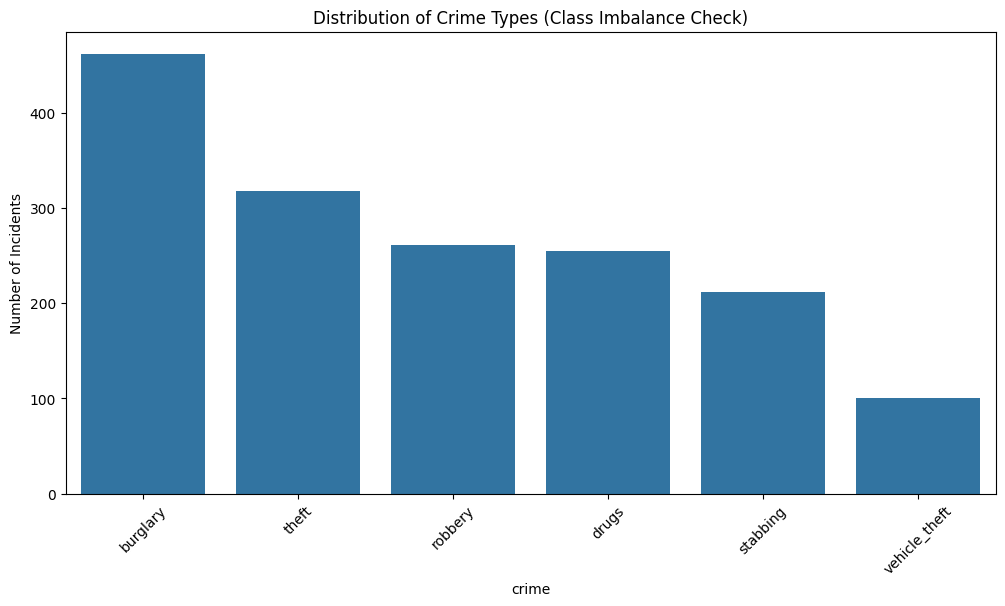

crime
burglary         462
theft            318
robbery          261
drugs            255
stabbing         212
vehicle_theft    100
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(12, 6))
sns.countplot(data=crime_df, x='crime', order=crime_df['crime'].value_counts().index)
plt.title('Distribution of Crime Types (Class Imbalance Check)')
plt.xticks(rotation=45)
plt.ylabel('Number of Incidents')
plt.show()

# Print exact counts for your report
print(crime_df['crime'].value_counts())

### Time-Binning


#### Devide the 24-hour day in to blocks[(Night)(Morning)(Afternoon)(Evening)]




In [12]:
#Create time bins-> devide the 24-hour day in to blocks

#Extract hour and create bins
crime_df['hour'] = pd.to_datetime(crime_df['time']).dt.hour

# Define bins 0-6 (Night), 6-12 (Morning), 12-18 (Afternoon), 18-24 (Evening)
bins = [0, 6, 12, 18, 24]
labels = ['night', 'morning', 'afternoon', 'evening']
crime_df['time_bin'] = pd.cut(crime_df['hour'], bins=bins, labels=labels, right=False)
crime_df['time_bin'] = pd.Categorical(crime_df['time_bin'], categories=labels, ordered=True)

/tmp/ipython-input-1272401930.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_df['hour'] = pd.to_datetime(crime_df['time']).dt.hour


#### Geospatial Incident Validation

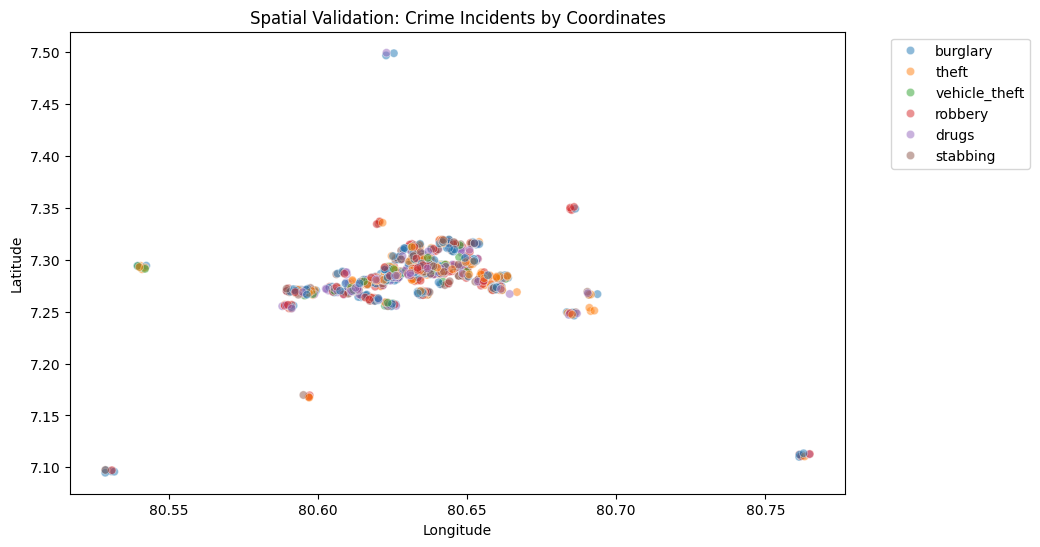

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=crime_df, x='longitude', y='latitude', hue='crime', alpha=0.5)
plt.title('Spatial Validation: Crime Incidents by Coordinates')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
# Fixed the 'loc' error here: changed '2' to 'upper left'
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [14]:
crime_df


,crime,location,date,sex,victim_ethnicity,victim_age,time,weather,latitude,longitude,...,gn_population,gn_distance_m,victim_ethnicity,status_report,month,day_of_week,is_weekend,year,hour,time_bin
0,burglary,mulgampola,2019-12-31,f,muslim,54,08:17:00,Cloudy,7.280544,80.616500,...,21826,311.8,muslim,Valid,12,1,0,2019,8,morning
1,burglary,car park,2020-01-04,m,sinhala,42,02:00:00,Rainy,7.283445,80.619385,...,8913,352.4,sinhala,Valid,1,5,1,2020,2,night
2,theft,bus stand,2020-01-08,f,sinhala,20,21:01:00,Rainy,7.256425,80.590461,...,16411,518.6,sinhala,Valid,1,2,0,2020,21,evening
3,vehicle_theft,aniwatte,2020-01-10,m,sinhala,29,12:10:00,Cloudy,7.290058,80.622438,...,1107,381.5,sinhala,Valid,1,4,0,2020,12,afternoon
4,robbery,dutugamunu mawatha,2020-01-11,m,sinhala,59,02:39:00,Rainy,7.312344,80.645687,...,1293,322.6,sinhala,Valid,1,5,1,2020,2,night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1603,drugs,walespark,2025-07-30,m,sinhala,65,09:19:00,Rainy,7.291772,80.636707,...,11613,518.0,sinhala,Valid,7,2,0,2025,9,morning
1604,drugs,peradeniya road,2025-08-16,m,sinhala,59,04:38:00,Rainy,7.280930,80.619477,...,18808,353.7,sinhala,Valid,8,5,1,2025,4,night
1605,robbery,provincial education department,2025-09-13,f,sinhala,50,07:25:00,Rainy,7.290341,80.633563,...,2198,315.0,sinhala,Valid,9,5,1,2025,7,morning
1606,robbery,post office,2025-09-17,f,sinhala,61,20:12:00,Rainy,7.292186,80.633475,...,6925,335.7,sinhala,Valid,9,2,0,2025,20,evening


### Spatial Feature Aggregation

This code converts your list of individual crime incidents into a neat summary table that shows the total number of crimes for each gd division and week.

In [15]:
#The primary key -> gn_pcode
# Convert date to a weekly period
crime_df['week_start'] = pd.to_datetime(crime_df['date']).dt.to_period('W').dt.start_time

# Group by Date and GN Division
weekly_aggregated = crime_df.groupby([
    'week_start', 'gn_pcode', 'gn_division', 'gn_population',
    'land_use_type'
], observed=True).size().reset_index(name='total_crimes')

# Sort by date and division for a clear timeline
weekly_aggregated = weekly_aggregated.sort_values(by=['week_start', 'gn_division'])



In [16]:
weekly_aggregated

,week_start,gn_pcode,gn_division,gn_population,land_use_type,total_crimes
0,2019-12-30,LK2130105,Katukele West,8913,Commercial,1
1,2019-12-30,LK2130170,Welata,21826,General Urban,1
3,2020-01-06,LK2130100,Aniwatta East,1107,General Urban,1
2,2020-01-06,LK2130050,Aruppala East,1293,General Urban,1
5,2020-01-06,LK2139135,Penideniya,16411,Commercial,1
...,...,...,...,...,...,...
1440,2025-07-28,LK2130120,Mahanuwara,11613,Commercial,1
1441,2025-08-11,LK2130165,Suduhumpala West,18808,General Urban,1
1442,2025-09-08,LK2130145,Bogambara,2198,Commercial,1
1443,2025-09-15,LK2130115,Ihala Katukele,6925,Commercial,1


### Spatio Temporal Grid Sampling

- Collect every unique week and every gn division’s details
- Creates a master schedule that lists every gn division’s for every single week
- Counts how many of each specific crime type happened in every gn division during each week
- Counts how many crimes occurred during each time of day (such as Night, Morning, or Afternoon) for every gn division each week
- Combine all the weekly crime counts and neighborhood details into one master table and then labels each row to show whether specific crimes occurred in the following week.
- Creates a final goal label indicating if any crime at all will occur next week

In [17]:
#Prepare unique values
all_weeks = weekly_aggregated['week_start'].unique()
all_gn_codes = weekly_aggregated['gn_pcode'].unique()
all_gn = all_gn = (weekly_aggregated
          .groupby('gn_pcode', as_index=False)
          .agg({
              'gn_division': 'first',
              'gn_population': 'first',
              'land_use_type': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
          }))

#CREATE THE MASTER GRID
index = pd.MultiIndex.from_product(
    [all_weeks, all_gn_codes],
    names=['week_start', 'gn_pcode']
)
master_grid = pd.DataFrame(index=index).reset_index()

# PIVOT CRIME TYPES (This creates columns for each unique value in 'crime' column)
crime_pivot = crime_df.pivot_table(
    index=['week_start', 'gn_pcode'],
    columns='crime',
    aggfunc='size',
    fill_value=0
).reset_index()

#Pivot Time Bins
time_pivot = crime_df.pivot_table(
    index=['week_start', 'gn_pcode'],
    columns='time_bin',
    aggfunc='size',
    fill_value=0
).reset_index()

# MERGE EVERYTHING
final_grid = pd.merge(master_grid, all_gn, on='gn_pcode', how='left')
final_grid = pd.merge(final_grid, weekly_aggregated[['week_start', 'gn_pcode', 'total_crimes']], on=['week_start', 'gn_pcode'], how='left')
final_grid = pd.merge(final_grid, crime_pivot, on=['week_start', 'gn_pcode'], how='left')
final_grid = pd.merge(final_grid, time_pivot, on=['week_start', 'gn_pcode'], how='left')

final_grid = final_grid.fillna(0)

# SORT FOR TIME-SERIES CONSISTENCY
final_grid = final_grid.sort_values(['gn_pcode', 'week_start'])

#AUTOMATICALLY DETECT CRIME TYPES
unique_crimes = crime_df['crime'].unique().tolist()

for crime in unique_crimes:
    # Use the exact column name created by the pivot table
    target_col_name = f'target_{crime.lower().replace(" ", "_")}_next_week'

    # Shift the specific crime count by -1 (look into the future)
    final_grid[target_col_name] = final_grid.groupby('gn_pcode')[crime].shift(-1)

    # Convert to binary: 1 if specific crime happens next week, else 0
    final_grid[target_col_name] = (final_grid[target_col_name] > 0).astype(int)

#KEEP TOTAL TARGET
final_grid['target_next_week_total'] = final_grid.groupby('gn_pcode')['total_crimes'].shift(-1)
final_grid['target_next_week_total'] = (final_grid['target_next_week_total'] > 0).astype(int)

# Drop the last row for each GN since we can't see the "future" for the latest week
final_grid = final_grid.dropna(subset=[f'target_{c.lower().replace(" ", "_")}_next_week' for c in unique_crimes])



/tmp/ipython-input-240717803.py:28: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  time_pivot = crime_df.pivot_table(


In [18]:
final_grid


,week_start,gn_pcode,gn_division,gn_population,land_use_type,total_crimes,burglary,drugs,robbery,stabbing,...,morning,afternoon,evening,target_burglary_next_week,target_theft_next_week,target_vehicle_theft_next_week,target_robbery_next_week,target_drugs_next_week,target_stabbing_next_week,target_next_week_total
48,2019-12-30,LK2106015,Dehiwatta,3133,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
120,2020-01-06,LK2106015,Dehiwatta,3133,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
192,2020-01-13,LK2106015,Dehiwatta,3133,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
264,2020-01-20,LK2106015,Dehiwatta,3133,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
337,2020-01-27,LK2106015,Dehiwatta,3133,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19652,2025-07-28,LK2154140,Pitakanda,16712,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
19724,2025-08-11,LK2154140,Pitakanda,16712,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
19796,2025-09-08,LK2154140,Pitakanda,16712,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
19868,2025-09-15,LK2154140,Pitakanda,16712,General Urban,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


### Trend and Seasonality Extraction




- Labels month with the corresponding Sri Lankan monsoon season.
- Flag to show if a specific week contains a public holiday.
- Counts the number of weeks since the very first record
- Calculate the average number of each crime type over the previous four weeks
- Calculate the average of all crimes combined over the previous month

In [19]:
#Extract Basic Time Components
final_grid['month'] = final_grid['week_start'].dt.month

# Map the Season -> weather patterns
def get_season(month):
    if month in [12, 1, 2]: return 'NE_monsoon'
    if month in [3, 4]: return 'first_inter'
    if month in [5, 6, 7, 8, 9]: return 'SW_monsoon'
    return 'second_inter'


### Feature Engineering

In [20]:
final_grid['season'] = final_grid['month'].apply(get_season)
final_grid = pd.get_dummies(final_grid, columns=['season'], prefix='season')

# Weekly Holiday Flag
crime_df['week_start'] = pd.to_datetime(crime_df['date']).dt.to_period('W').dt.start_time
weeks_with_holidays = crime_df[crime_df['is_holiday'] == 1]['week_start'].unique()
final_grid['has_holiday_in_week'] = final_grid['week_start'].isin(weeks_with_holidays).astype(int)

# Long-term Trend Indicator (Weeks from Start)
start_week = final_grid['week_start'].min()
final_grid['weeks_from_start'] = ((final_grid['week_start'] - start_week).dt.days // 7).astype(int)

#Automatically detect all crime types from the data
unique_crimes = crime_df['crime'].unique().tolist()

# Calculate Shifted 4-week Rolling Averages for EACH crime
# This tells the model if 'Theft' or 'Assault' has been increasing lately
for crime in unique_crimes:
    col_name = f'{crime.lower().replace(" ", "_")}_trend_4w'
    final_grid[col_name] = final_grid.groupby('gn_pcode')[crime].transform(
        lambda x: x.rolling(window=4, min_periods=1).mean()
    ).shift(1).fillna(0) # SHIFT(1) is vital to prevent data leakage

# Calculate shifted 4-week rolling average of total crimes
# This gives the model a sense of overall "neighborhood activity"
final_grid['total_crime_trend_4w'] = final_grid.groupby('gn_pcode')['total_crimes'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
).shift(1).fillna(0)

In [21]:
final_grid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19953 entries, 48 to 19940
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   week_start                      19953 non-null  datetime64[ns]
 1   gn_pcode                        19953 non-null  object        
 2   gn_division                     19953 non-null  object        
 3   gn_population                   19953 non-null  int64         
 4   land_use_type                   19953 non-null  object        
 5   total_crimes                    19953 non-null  float64       
 6   burglary                        19953 non-null  float64       
 7   drugs                           19953 non-null  float64       
 8   robbery                         19953 non-null  float64       
 9   stabbing                        19953 non-null  float64       
 10  theft                           19953 non-null  float64       
 11  vehicl

### Spatio-Temporal Engineering

- Creates "Time Lags" by looking back at how many specific crimes (like Theft or Assault) happened exactly one week and two weeks ago.
-  Records the total crime count from the previous two weeks to give the model a sense of recent overall activity.
- Group neighborhoods into districts
- Create Future Label for every specific crime type -> converts those future counts into a simple "Yes (1)" or "No (0)"

In [22]:
# Sort to ensure time is linear for each GN and Crime Type
final_grid = final_grid.sort_values(by=['gn_pcode', 'week_start'])

# DYNAMICALLY identify all specific crime types
unique_crimes = crime_df['crime'].unique().tolist()

# Temporal Lags for EACH specific crime
for crime in unique_crimes:
    crime_key = crime.lower().replace(" ", "_")
    # 1-week and 2-week history for the specific crime
    final_grid[f'{crime_key}_lag_1w'] = final_grid.groupby('gn_pcode')[crime].shift(1).fillna(0)
    final_grid[f'{crime_key}_lag_2w'] = final_grid.groupby('gn_pcode')[crime].shift(2).fillna(0)

# Correctly handle the trend lag (already shifted in the previous step, just ensure name matches)
# If you used 'total_crime_trend_4w' in the previous step, we use it here
final_grid['lag_total_1w'] = final_grid.groupby('gn_pcode')['total_crimes'].shift(1).fillna(0)
final_grid['lag_total_2w'] = final_grid.groupby('gn_pcode')['total_crimes'].shift(2).fillna(0)

# District Proxy logic (Spatial Lag)
final_grid['district_id'] = final_grid['gn_pcode'].astype(str).str[:4]

# We calculate the district average of total crimes to give context of the surrounding area
dist_avg = final_grid.groupby(['week_start','district_id'])['total_crimes'].transform('mean')
final_grid['spatial_lag_1w'] = final_grid.groupby('gn_pcode')[dist_avg.name].shift(1).fillna(0)

# Cleanup
final_grid = final_grid.drop(columns=['district_id'])


### Class Imbalance Analysis

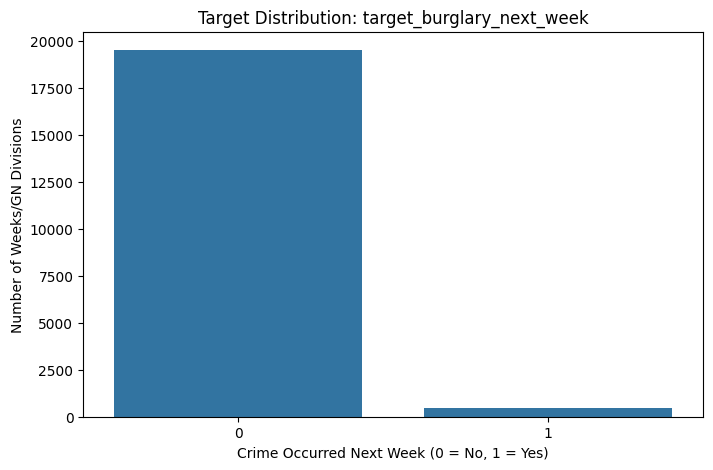

target_burglary_next_week
0    97.699594
1     2.300406
Name: proportion, dtype: float64


In [23]:
# Select one of your target columns to check imbalance (e.g., burglary)
target_to_check = 'target_burglary_next_week'

plt.figure(figsize=(8, 5))
sns.countplot(x=target_to_check, data=final_grid)
plt.title(f'Target Distribution: {target_to_check}')
plt.xlabel('Crime Occurred Next Week (0 = No, 1 = Yes)')
plt.ylabel('Number of Weeks/GN Divisions')
plt.show()

# Calculate the exact percentage to justify class weights
print(final_grid[target_to_check].value_counts(normalize=True) * 100)

### Feature Exclusion


In [24]:
final_grid = final_grid.drop(columns=['gn_division'])

In [25]:
final_grid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19953 entries, 48 to 19940
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   week_start                      19953 non-null  datetime64[ns]
 1   gn_pcode                        19953 non-null  object        
 2   gn_population                   19953 non-null  int64         
 3   land_use_type                   19953 non-null  object        
 4   total_crimes                    19953 non-null  float64       
 5   burglary                        19953 non-null  float64       
 6   drugs                           19953 non-null  float64       
 7   robbery                         19953 non-null  float64       
 8   stabbing                        19953 non-null  float64       
 9   theft                           19953 non-null  float64       
 10  vehicle_theft                   19953 non-null  float64       
 11  night 

### Encoding Categorical Variables

In [26]:
# One-Hot Encode Land Use
existing_categorical = [c for c in ['land_use_type'] if c in final_grid.columns]
final_grid = pd.get_dummies(final_grid, columns=existing_categorical)

# Label Encode the GN Code
le = LabelEncoder()
final_grid['gn_encoded'] = le.fit_transform(final_grid['gn_pcode'])

# Clean up Boolean columns
bool_cols = final_grid.select_dtypes(include=['bool']).columns
final_grid[bool_cols] = final_grid[bool_cols].astype(int)

cols_to_drop = ['gn_pcode', 'gn_division']
# Only drop if they exist in the dataframe to avoid errors
final_grid = final_grid.drop(columns=[c for c in cols_to_drop if c in final_grid.columns])

In [27]:
final_grid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19953 entries, 48 to 19940
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   week_start                      19953 non-null  datetime64[ns]
 1   gn_population                   19953 non-null  int64         
 2   total_crimes                    19953 non-null  float64       
 3   burglary                        19953 non-null  float64       
 4   drugs                           19953 non-null  float64       
 5   robbery                         19953 non-null  float64       
 6   stabbing                        19953 non-null  float64       
 7   theft                           19953 non-null  float64       
 8   vehicle_theft                   19953 non-null  float64       
 9   night                           19953 non-null  int64         
 10  morning                         19953 non-null  int64         
 11  aftern


### NaN Scrubbing

* Removing rows with missing/invalid values
* Replaces "infinite" numbers with zeros


In [28]:
# Dynamically build the list of all lag columns to scrub
# This includes the general lags AND the specific crime lags we created earlier
unique_crimes = crime_df['crime'].unique().tolist()
specific_lag_cols = [f'{c.lower().replace(" ", "_")}_lag_{i}w' for c in unique_crimes for i in [1, 2]]
general_lag_cols = ['lag_total_1w', 'lag_total_2w', 'spatial_lag_1w', 'total_crime_trend_4w']

# Combine all feature columns that must not be NaN
scrub_features = specific_lag_cols + general_lag_cols

# Add the Target columns to the scrub list
# We must drop the last week of data for each GN because we don't know the "future" yet
target_cols = [f'target_{c.lower().replace(" ", "_")}_next_week' for c in unique_crimes]
all_scrub_cols = scrub_features  + target_cols
print(f"Rows before scrubbing: {len(final_grid)}")

# Drop NaNs
# The model cannot process 'None' in features or targets during training
final_grid = final_grid.dropna(subset=all_scrub_cols)
final_grid = final_grid.replace([np.inf, -np.inf], 0)
print(f"Rows after scrubbing: {len(final_grid)}")
print(f"Rows dropped: {len(final_grid) - len(final_grid)}")

Rows before scrubbing: 19953
Rows after scrubbing: 19953
Rows dropped: 0


In [29]:
final_grid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19953 entries, 48 to 19940
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   week_start                      19953 non-null  datetime64[ns]
 1   gn_population                   19953 non-null  int64         
 2   total_crimes                    19953 non-null  float64       
 3   burglary                        19953 non-null  float64       
 4   drugs                           19953 non-null  float64       
 5   robbery                         19953 non-null  float64       
 6   stabbing                        19953 non-null  float64       
 7   theft                           19953 non-null  float64       
 8   vehicle_theft                   19953 non-null  float64       
 9   night                           19953 non-null  int64         
 10  morning                         19953 non-null  int64         
 11  aftern

#### Independent and Dependent variable

**Dependent variable**

    target_burglary_next_week
    target_theft_next_week
    target_vehicle_theft_next_week
    target_robbery_next_week
    target_drugs_next_week
    target_stabbing_next_week
    target_next_week_total (The aggregate outcome)

**Independent variable**

    The rest

#Temporal Train-Test Split


- Train - model uses to learn
- Test - to measure of how accurately the model predicts crime
- Validation - tune the model's settings
- Inference - current-week data used to generate actual predictions for the upcoming week (When you run your Flask API, it uses the model (predict risk for the next week using this inference_df)

In [30]:
# Define features (exclude metadata and targets)
exclude = ['gn_division', 'week_start', 'gn_pcode', 'total_crimes'] + \
          [col for col in final_grid.columns if 'target_' in col]

features = [col for col in final_grid.columns if col not in exclude]


print("="*70)
print("CREATING TRAIN/VALIDATION/TEST SPLIT")
print("="*70)

#IDENTIFY INFERENCE DATA

latest_week = final_grid['week_start'].max()
all_gn_divisions = final_grid['gn_encoded'].unique()

print(f"Total GN divisions: {len(all_gn_divisions)}")
print(f"Latest week: {latest_week}")

# Get each GN's most recent data
inference_rows = []
for gn in all_gn_divisions:
    gn_data = final_grid[final_grid['gn_encoded'] == gn].sort_values('week_start')
    if not gn_data.empty:
        latest_row = gn_data.iloc[-1].copy()
        # Add this check to see what the value is right now
        # print(f"DEBUG: GN {gn} has gn_encoded value: {latest_row['gn_encoded']}")
        inference_rows.append(latest_row)

inference_df = pd.DataFrame(inference_rows)

# CHECK THE OUTPUT HERE
print("\n--- FIRST 5 ROWS OF INFERENCE DF ---")
print(inference_df[['gn_encoded']].head())

unique_count = inference_df['gn_encoded'].nunique()
print(f"✅ Final Inference Data Check: {len(inference_df)} rows for {unique_count} unique GN Divisions.")

if len(inference_df) != 72:
    print("⚠️ WARNING: You do not have 72 divisions. Check your data source!")

inference_df.to_parquet('inference_data_latest.parquet', index=False)

print(f"\nInference columns: {inference_df.columns.tolist()}")
assert 'gn_encoded' in inference_df.columns, "Missing gn_encoded!"



# Get all data EXCEPT the latest week
train_test_pool = final_grid[final_grid['week_start'] < latest_week].copy()
target_cols = [col for col in train_test_pool.columns if 'target_' in col and '_next_week' in col]
train_test_pool = train_test_pool.dropna(subset=target_cols, how='all')


print(f"\n📈 Target distributions across ALL crime types:")
for target_col in sorted(target_cols):
    crime_name = target_col.replace('target_', '').replace('_next_week', '')
    pos_count = train_test_pool[target_col].sum()
    total = len(train_test_pool)
    pos_rate = (pos_count / total) * 100
    print(f"   {crime_name.upper():15s}: {int(pos_count):4d} positive ({pos_rate:5.2f}%)")


# TIME-BASED SPLIT (RECOMMENDED FOR TIME-SERIES) ---
train_test_pool = train_test_pool.sort_values('week_start')

# Calculate split points
n_total = len(train_test_pool)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
# Remaining 15% for test

train_df = train_test_pool.iloc[:n_train]
val_df = train_test_pool.iloc[n_train:n_train+n_val]
test_df = train_test_pool.iloc[n_train+n_val:]


# VALIDATION CHECKS
print("\n" + "="*70)
print("VALIDATION CHECKS FOR ALL CRIME TYPES")
print("="*70)

all_valid = True
validation_results = {}

for target_col in sorted(target_cols):
    crime_name = target_col.replace('target_', '').replace('_next_week', '')

    train_pos = train_df[target_col].sum()
    val_pos = val_df[target_col].sum()
    test_pos = test_df[target_col].sum()

    validation_results[crime_name] = {
        'train': train_pos,
        'val': val_pos,
        'test': test_pos
    }

    # Check for critical issues
    if train_pos == 0:
        print(f"{crime_name.upper()}: NO positive cases in TRAINING set")
        all_valid = False
    elif test_pos == 0:
        print(f"{crime_name.upper()}: NO positive cases in TEST set")
        all_valid = False
    elif val_pos == 0:
        print(f"{crime_name.upper()}: NO positive cases in VALIDATION set")
    else:
        print(f"{crime_name.upper()}: Train={int(train_pos)}, Val={int(val_pos)}, Test={int(test_pos)}")

if all_valid:
    print("\nAll crime types have sufficient positive cases in train AND test sets!")
else:
    print("\nSome crime types have issues - they may not be trainable")
    print("    Training notebook should check target validity before training")




CREATING TRAIN/VALIDATION/TEST SPLIT
Total GN divisions: 72
Latest week: 2025-09-22 00:00:00

--- FIRST 5 ROWS OF INFERENCE DF ---
       gn_encoded
19929           0
19936           1
19937           2
19928           3
19917           4
✅ Final Inference Data Check: 72 rows for 72 unique GN Divisions.

Inference columns: ['week_start', 'gn_population', 'total_crimes', 'burglary', 'drugs', 'robbery', 'stabbing', 'theft', 'vehicle_theft', 'night', 'morning', 'afternoon', 'evening', 'target_burglary_next_week', 'target_theft_next_week', 'target_vehicle_theft_next_week', 'target_robbery_next_week', 'target_drugs_next_week', 'target_stabbing_next_week', 'target_next_week_total', 'month', 'season_NE_monsoon', 'season_SW_monsoon', 'season_first_inter', 'season_second_inter', 'has_holiday_in_week', 'weeks_from_start', 'burglary_trend_4w', 'theft_trend_4w', 'vehicle_theft_trend_4w', 'robbery_trend_4w', 'drugs_trend_4w', 'stabbing_trend_4w', 'total_crime_trend_4w', 'burglary_lag_1w', 'burglary

### Feature Scaling

In [39]:

exclude_cols = [
    'week_start', 'gn_division', 'gn_pcode', 'total_crimes'
] + [col for col in train_df.columns if 'target_' in col]

# Dynamically pick up all other 45 features
cols_to_scale = [col for col in train_df.columns if col not in exclude_cols]

scaler = StandardScaler()

#Fit ONLY on training data to prevent data leakage
scaler.fit(train_df[cols_to_scale])

print("\n" + "="*70)
print("APPLYING FEATURE SCALING")
print("="*70)

# Create copies to avoid SettingWithCopyWarning
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()
inference_df = inference_df.copy()

# Apply scaling transformation
print(f"\n Scaling {len(cols_to_scale)} features...")

# We use scaler.feature_names_in_ to ensure we match the exact order the scaler
expected_order = scaler.feature_names_in_.tolist()

train_df[expected_order] = scaler.transform(train_df[expected_order])
val_df[expected_order] = scaler.transform(val_df[expected_order])
test_df[expected_order] = scaler.transform(test_df[expected_order])

# For inference, only scale if columns exist
inference_cols = [c for c in expected_order if c in inference_df.columns]
if len(inference_cols) == len(expected_order):
    inference_df[expected_order] = scaler.transform(inference_df[expected_order])
else:
    print(" Warning: Inference data missing some columns required by scaler!")


print("✅ Scaling complete!")

#Ensure target columns are NOT scaled
target_cols = [col for col in train_df.columns if 'target_' in col]
for target_col in target_cols[:2]:  # Check first 2 targets
    unique_vals = sorted(train_df[target_col].dropna().unique())
    if set(unique_vals) == {0.0, 1.0}:
        print(f"✅ {target_col}: Still binary (0, 1)")
    else:
        print(f"❌ {target_col}: VALUES CHANGED - {unique_vals}")



APPLYING FEATURE SCALING

 Scaling 44 features...
✅ Scaling complete!
✅ target_burglary_next_week: Still binary (0, 1)
✅ target_theft_next_week: Still binary (0, 1)


### Handle Class Imbalance

Use - Class Weights
* Class weights are used to handle imbalanced datasets by giving more importance to minority classes during model training. Class weights increase the penalty for misclassifying underrepresented classes, helping the model learn their patterns better and improving overall prediction fairness and accuracy.



In [40]:

# ============================================================================
# STEP 1: CALCULATE AND SAVE CLASS WEIGHTS FOR ALL CRIME TYPES
# ============================================================================

print("\n" + "="*80)
print("CALCULATING CLASS WEIGHTS FOR ALL CRIME TYPES")
print("="*80)

# Get all target columns
target_cols = [col for col in train_df.columns
               if 'target_' in col and '_next_week' in col and col != 'target_next_week_total']

# Dictionary to store all class weights
all_class_weights = {}

# Calculate weights for each crime type
for target_col in sorted(target_cols):
    crime_name = target_col.replace('target_', '').replace('_next_week', '')
    y_train = train_df[target_col].dropna().astype(int)

    # Calculate class distribution
    n_total = len(y_train)
    n_positive = y_train.sum()
    n_negative = n_total - n_positive
    pos_ratio = (n_positive / n_total) * 100
    imbalance_ratio = n_negative / n_positive if n_positive > 0 else 1

    # Standard balanced weights (sklearn default)
    classes = np.array([0, 1])
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    balanced_weights = {0: float(weights[0]), 1: float(weights[1])}

    # ✅ BOOSTED WEIGHTS - More aggressive for extreme imbalance
    boosted_weights = {
        0: 1.0,
        1: min(imbalance_ratio * 2.0, 150)  # 2x boost, cap at 150
    }

    # Store both versions
    all_class_weights[crime_name] = {
        'class_weights': balanced_weights,
        'class_weights_boosted': boosted_weights,
        'n_total': int(n_total),
        'n_positive': int(n_positive),
        'n_negative': int(n_negative),
        'positive_ratio': float(pos_ratio),
        'imbalance_ratio': float(imbalance_ratio)
    }

    # Print information
    print(f"\n{crime_name.upper():20s}")
    print(f"  Total samples:    {n_total:,}")
    print(f"  No Crime (0):     {n_negative:,} ({100-pos_ratio:.2f}%)")
    print(f"  Crime (1):        {n_positive:,} ({pos_ratio:.2f}%)")
    print(f"  Imbalance Ratio:  {imbalance_ratio:.1f}:1")
    print(f"  Balanced Weight:  {{0: {balanced_weights[0]:.3f}, 1: {balanced_weights[1]:.3f}}} "
          f"({balanced_weights[1]/balanced_weights[0]:.1f}x)")
    print(f"  Boosted Weight:   {{0: {boosted_weights[0]:.3f}, 1: {boosted_weights[1]:.3f}}} "
          f"({boosted_weights[1]:.1f}x) ← USE THIS")

print("\n" + "="*80)
print("✅ CLASS WEIGHTS CALCULATED (USE BOOSTED FOR BETTER RECALL)")
print("="*80)




CALCULATING CLASS WEIGHTS FOR ALL CRIME TYPES

BURGLARY            
  Total samples:    13,916
  No Crime (0):     13,608 (97.79%)
  Crime (1):        308 (2.21%)
  Imbalance Ratio:  44.2:1
  Balanced Weight:  {0: 0.511, 1: 22.591} (44.2x)
  Boosted Weight:   {0: 1.000, 1: 88.364} (88.4x) ← USE THIS

DRUGS               
  Total samples:    13,916
  No Crime (0):     13,726 (98.63%)
  Crime (1):        190 (1.37%)
  Imbalance Ratio:  72.2:1
  Balanced Weight:  {0: 0.507, 1: 36.621} (72.2x)
  Boosted Weight:   {0: 1.000, 1: 144.484} (144.5x) ← USE THIS

ROBBERY             
  Total samples:    13,916
  No Crime (0):     13,731 (98.67%)
  Crime (1):        185 (1.33%)
  Imbalance Ratio:  74.2:1
  Balanced Weight:  {0: 0.507, 1: 37.611} (74.2x)
  Boosted Weight:   {0: 1.000, 1: 148.443} (148.4x) ← USE THIS

STABBING            
  Total samples:    13,916
  No Crime (0):     13,747 (98.79%)
  Crime (1):        169 (1.21%)
  Imbalance Ratio:  81.3:1
  Balanced Weight:  {0: 0.506, 1: 41.172

In [41]:
# ============================================================================
# STEP 2: VALIDATION - CHECK CLASS WEIGHTS ARE REASONABLE
# ============================================================================

print("\n" + "="*80)
print("VALIDATION: CLASS WEIGHT SUMMARY")
print("="*80)

print("\nCrime Type          Pos%    Imbalance   Weight(0)  Weight(1)  Ratio")
print("-" * 80)
for crime_name, info in sorted(all_class_weights.items()):
    cw = info['class_weights']
    print(f"{crime_name:18s}  {info['positive_ratio']:5.2f}%  "
          f"{info['imbalance_ratio']:6.1f}:1    "
          f"{cw[0]:6.3f}     {cw[1]:6.3f}     "
          f"{cw[1]/cw[0]:5.1f}x")



VALIDATION: CLASS WEIGHT SUMMARY

Crime Type          Pos%    Imbalance   Weight(0)  Weight(1)  Ratio
--------------------------------------------------------------------------------
burglary             2.21%    44.2:1     0.511     22.591      44.2x
drugs                1.37%    72.2:1     0.507     36.621      72.2x
robbery              1.33%    74.2:1     0.507     37.611      74.2x
stabbing             1.21%    81.3:1     0.506     41.172      81.3x
theft                1.65%    59.5:1     0.508     30.252      59.5x
vehicle_theft        0.52%   192.3:1     0.503     96.639     192.3x


In [42]:
# ============================================================================
# STEP 3: CREATE HELPER FUNCTION TO RETRIEVE WEIGHTS
# ============================================================================

def get_class_weights_for_crime(crime_type):

    if crime_type in all_class_weights:
        return all_class_weights[crime_type]['class_weights']
    else:
        available = ', '.join(all_class_weights.keys())
        raise ValueError(f"Crime type '{crime_type}' not found. Available: {available}")



In [43]:
final_grid['gn_encoded'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71])

In [44]:

# ============================================================================
# STEP 4: SAVE CLASS WEIGHTS TO FILE (FOR MODEL TRAINING NOTEBOOK)
# ============================================================================

# This will be saved along with your other preprocessed data
# You'll load this in your model training notebook

print("\n" + "="*80)
print("SAVING CLASS WEIGHTS")
print("="*80)

# Note: The actual saving will happen in the next cell with other artifacts
# We're just preparing the data structure here

print(f"\n✅ Class weights ready to save for {len(all_class_weights)} crime types:")
for crime_name in sorted(all_class_weights.keys()):
    print(f"   • {crime_name}")



SAVING CLASS WEIGHTS

✅ Class weights ready to save for 6 crime types:
   • burglary
   • drugs
   • robbery
   • stabbing
   • theft
   • vehicle_theft


In [46]:

# Create directory if it doesn't exist
save_path = '/content/drive/MyDrive/DSGP/'
os.makedirs(save_path, exist_ok=True)

# Save the Training set
train_df.to_parquet(os.path.join(save_path, 'train_set_processed.parquet'))

# Save validation set
val_df.to_parquet(os.path.join(save_path, 'val_set_processed.parquet'))

# Save the Test set
test_df.to_parquet(os.path.join(save_path, 'test_set_processed.parquet'))

#Save the Inference Data
inference_df.to_parquet(os.path.join(save_path, 'inference_data_latest.parquet'))

# Save the Scaler
joblib.dump(scaler, os.path.join(save_path, 'feature_scaler.joblib'))


# Save the Feature List
with open(os.path.join(save_path, 'feature_list.json'), 'w') as f:
     json.dump(cols_to_scale, f, indent=2)
print(f"✅ Saved feature list: {len(features)} columns")


# SAVE CLASS WEIGHTS
print("\n📁 Saving class weights for all crime types...")
with open(os.path.join(save_path, 'class_weights.json'), 'w') as f:
    json.dump(all_class_weights, f, indent=2)
print(f"   ✅ Saved: class_weights.json ({len(all_class_weights)} crime types)")

# List all crime types saved
print("\n   Crime types with class weights:")
for crime_name in sorted(all_class_weights.keys()):
    info = all_class_weights[crime_name]
    print(f"      • {crime_name:18s} (Pos: {info['positive_ratio']:5.2f}%, "
          f"Weight ratio: {info['class_weights'][1]/info['class_weights'][0]:.1f}x)")


✅ Saved feature list: 44 columns

📁 Saving class weights for all crime types...
   ✅ Saved: class_weights.json (6 crime types)

   Crime types with class weights:
      • burglary           (Pos:  2.21%, Weight ratio: 44.2x)
      • drugs              (Pos:  1.37%, Weight ratio: 72.2x)
      • robbery            (Pos:  1.33%, Weight ratio: 74.2x)
      • stabbing           (Pos:  1.21%, Weight ratio: 81.3x)
      • theft              (Pos:  1.65%, Weight ratio: 59.5x)
      • vehicle_theft      (Pos:  0.52%, Weight ratio: 192.3x)


###Mapping of the GN division

In [47]:
import json

# Replace 'le' with the variable name of your LabelEncoder
# This creates a dictionary: {0: "Name1", 1: "Name2", ...}
mapping = {int(i): name for i, name in enumerate(le.classes_)}

# Save it to your project folder
mapping_path = '/content/drive/MyDrive/DSGP/gn_name_mapping.json' # Update path
with open(mapping_path, 'w') as f:
    json.dump(mapping, f)

print("✅ Mapping file saved!")

✅ Mapping file saved!
